# Bitcoin Price Prediction — RF vs XGBoost vs GRU

Three models, engineered features, holdout + walk-forward evaluation.

**Models:** Random Forest · XGBoost · GRU (proper sequential: LOOKBACK timesteps of Close prices)  
**Target:** Log-return `log(close[t] / close[t-1])` → reconstructed to price for evaluation  
**Features:** 100-day lag window · RSI(14) · MACD(12,26,9) · rolling std(30) · yesterday's return (all leak-free)  
**Evaluation:** 70/30 holdout + walk-forward CV (retrain trees every K steps)

Tune the `CONFIG` cell to balance speed vs accuracy.


In [1]:

# ── Cell 1: Imports & CONFIG ─────────────────────────────────────────────────
from __future__ import annotations
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import joblib

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    xgb = None
    HAS_XGB = False
    print("⚠ xgboost not found — install with:  pip install xgboost")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
warnings.filterwarnings("ignore")

# ── Tunable settings ─────────────────────────────────────────────────────────
CONFIG = dict(
    ticker       = "BTC-USD",
    start        = "2015-01-01",
    seq_len      = 100,
    train_frac   = 0.70,
    n_estimators = 100,    # RF / XGB trees (lower = faster)
    gru_epochs   = 3,      # GRU training epochs
    gru_lookback = 20,     # timesteps fed into the GRU sequence
    max_iters    = 200,    # walk-forward steps (None = full test set)
    retrain_k    = 7,      # retrain RF/XGB every K steps
    seed         = 42,
)
print("CONFIG:", CONFIG)


CONFIG: {'ticker': 'BTC-USD', 'start': '2015-01-01', 'seq_len': 100, 'train_frac': 0.7, 'n_estimators': 100, 'gru_epochs': 3, 'gru_lookback': 20, 'max_iters': 200, 'retrain_k': 7, 'seed': 42}


In [2]:

# ── Cell 2: Feature engineering helpers ──────────────────────────────────────
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up   = delta.clip(lower=0).rolling(period).mean()
    down = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))

def macd_features(series: pd.Series, a=12, b=26, c=9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig

def build_features(df: pd.DataFrame, seq_len: int) -> pd.DataFrame:
    d = df.copy()
    # ALL indicators shifted by 1 to avoid lookahead leakage:
    # at prediction time for day t, only info up to day t-1 is available
    d["return"]   = d["Close"].pct_change().shift(1)  # yesterday's return
    d["std30"]    = d["Close"].rolling(30).std().shift(1)
    d["rsi14"]    = rsi(d["Close"]).shift(1)
    ml, ms        = macd_features(d["Close"])
    d["macd"]     = ml.shift(1)
    d["macd_sig"] = ms.shift(1)
    d = d.dropna().reset_index(drop=True)
    # add lagged Close columns (lag_1 = yesterday's close, etc.)
    for i in range(1, seq_len + 1):
        d[f"lag_{i}"] = d["Close"].shift(i)
    d = d.dropna().reset_index(drop=True)
    return d

print("Feature helpers defined.")


Feature helpers defined.


In [3]:

# ── Cell 3: Download and prepare data ────────────────────────────────────────
raw = yf.download(CONFIG["ticker"], start=CONFIG["start"])
# Flatten MultiIndex columns (yfinance >= 0.2 returns these for single tickers)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw = raw.reset_index()[["Date", "Close"]]

df  = build_features(raw, seq_len=CONFIG["seq_len"])

seq_len    = CONFIG["seq_len"]
lag_cols   = [f"lag_{i}" for i in range(1, seq_len + 1)]
extra_cols = ["std30", "rsi14", "macd", "macd_sig", "return"]
feature_cols = lag_cols + extra_cols

X     = df[feature_cols].copy()
dates = df["Date"].copy()

# ── Target: log-return (stationary — no price-range extrapolation issue) ─────
# log(close[t] / close[t-1])  =  log(close[t] / lag_1[t])
# lag_1 is already in the feature matrix, so this never produces NaN
y = np.log(df["Close"] / df["lag_1"])

split = int(len(X) * CONFIG["train_frac"])
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]
dates_test = dates.iloc[split:].reset_index(drop=True)

# Kept for price reconstruction during evaluation
close_test_actual = df["Close"].iloc[split:].values  # actual close prices in test set
close_prev_test   = X_test["lag_1"].values           # previous close for each test point

print(f"Total samples: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Target: log-return  (train mean={float(y_train.mean()):.5f}, std={float(y_train.std()):.4f})")
print(f"Features: {len(feature_cols)}  (lag×{seq_len} + 5 indicators, all leak-free)")


[*********************100%***********************]  1 of 1 completed

Total samples: 4005 | Train: 2803 | Test: 1202
Target: log-return  (train mean=0.00154, std=0.0384)
Features: 105  (lag×100 + 5 indicators, all leak-free)


In [4]:

# ── Cell 4: Scale features (fit on train only) ───────────────────────────────
# Features (X): MinMaxScaler — lag prices span very different ranges
# Target (y):   StandardScaler — log-returns are ~Normal(0, σ), can go negative
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# 3-D sequences for GRU: (n_samples, LOOKBACK, 1)
# lag_1 = yesterday, lag_LOOKBACK = oldest → reverse to chronological order
LOOKBACK = CONFIG["gru_lookback"]
gru_lag_idx = list(range(LOOKBACK - 1, -1, -1))  # [19, 18, ..., 0] for LOOKBACK=20

X_train_gru = X_train_s[:, gru_lag_idx].reshape(-1, LOOKBACK, 1)
X_test_gru  = X_test_s[:,  gru_lag_idx].reshape(-1, LOOKBACK, 1)

print("Scalers fitted.")
print(f"  X_train_s  : {X_train_s.shape}")
print(f"  X_train_gru: {X_train_gru.shape}  ← sequence (oldest → newest)")
print(f"  y_train_s  : mean={y_train_s.mean():.3f}, std={y_train_s.std():.3f}")


Scalers fitted.
  X_train_s  : (2803, 105)
  X_train_gru: (2803, 20, 1)  ← sequence (oldest → newest)
  y_train_s  : mean=0.000, std=1.000


In [5]:

# ── Cell 5: Train models (holdout) ───────────────────────────────────────────
rng = CONFIG["seed"]

# Random Forest
rf = RandomForestRegressor(n_estimators=CONFIG["n_estimators"], n_jobs=-1, random_state=rng)
rf.fit(X_train_s, y_train_s)
print("RF trained")

# XGBoost
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(n_estimators=CONFIG["n_estimators"],
                                   n_jobs=-1, random_state=rng, verbosity=0)
    xgb_model.fit(X_train_s, y_train_s)
    print("XGB trained")
else:
    xgb_model = None

# GRU — proper sequential model: LOOKBACK timesteps of normalized Close prices
gru_model = Sequential([
    GRU(64, input_shape=(LOOKBACK, 1)),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train_gru, y_train_s, epochs=CONFIG["gru_epochs"], batch_size=32, verbose=0)
print("GRU trained")


RF trained
XGB trained
GRU trained


In [6]:

# ── Cell 6: Holdout evaluation ───────────────────────────────────────────────
def metrics(y_true_raw, y_pred_raw):
    rmse = np.sqrt(np.mean((y_true_raw - y_pred_raw) ** 2))
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)
    return dict(RMSE=round(rmse, 2), MAE=round(mae, 2), R2=round(r2, 4))

def inv_logret(scaled_pred, close_prev):
    """Unscale log-return prediction → reconstruct price.
    price[t] = close_prev[t] * exp(log_return[t])
    """
    log_ret = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()
    return close_prev * np.exp(log_ret)

holdout = {}

rf_pred  = inv_logret(rf.predict(X_test_s), close_prev_test)
holdout["RF"] = metrics(close_test_actual, rf_pred)

if xgb_model:
    xgb_pred = inv_logret(xgb_model.predict(X_test_s), close_prev_test)
    holdout["XGBoost"] = metrics(close_test_actual, xgb_pred)

gru_pred = inv_logret(gru_model.predict(X_test_gru, verbose=0).ravel(), close_prev_test)
holdout["GRU"] = metrics(close_test_actual, gru_pred)

holdout_df = pd.DataFrame(holdout).T
print("=== Holdout metrics (price-reconstructed from predicted log-returns) ===")
print(holdout_df.to_string())


=== Holdout metrics (price-reconstructed from predicted log-returns) ===
            RMSE      MAE      R2
RF       2801.05  2057.68  0.9915
XGBoost  2165.74  1539.67  0.9949
GRU      1759.92  1183.42  0.9966


In [7]:

# ── Cell 7: Walk-forward evaluation ──────────────────────────────────────────
# Uses scaler fitted on training data — no re-fitting per step.
# RF/XGB are retrained every RETRAIN_K steps to save compute.

def walk_forward(rf_m, xgb_m, gru_m, X_tr, y_tr, X_te, y_te, close_prev, k, max_iters):
    n = min(len(X_te), max_iters) if max_iters else len(X_te)
    preds = {"RF": [], "XGBoost": [], "GRU": []}
    truth_prices = []

    Xw = X_tr.copy()
    yw = y_tr.copy()

    for i in range(n):
        xi_2d = X_te[i:i+1]
        xi_gru = xi_2d[:, gru_lag_idx].reshape(1, LOOKBACK, 1)
        cp = np.array([close_prev[i]])

        preds["RF"].append(inv_logret(rf_m.predict(xi_2d), cp)[0])
        if xgb_m:
            preds["XGBoost"].append(inv_logret(xgb_m.predict(xi_2d), cp)[0])
        preds["GRU"].append(inv_logret(gru_m.predict(xi_gru, verbose=0).ravel(), cp)[0])
        truth_prices.append(close_test_actual[i])

        # expand window and retrain tree models every k steps
        Xw = np.vstack([Xw, xi_2d])
        yw = np.append(yw, y_te[i])
        if (i + 1) % k == 0:
            rf_m.fit(Xw, yw)
            if xgb_m:
                xgb_m.fit(Xw, yw)

        if (i + 1) % 50 == 0:
            print(f"  walk-forward step {i+1}/{n}")

    truth_arr = np.array(truth_prices)
    wf_results = {}
    for name, p in preds.items():
        if p:
            wf_results[name] = metrics(truth_arr, np.array(p))
    return wf_results

print(f"Running walk-forward (max {CONFIG['max_iters']} steps, retrain every {CONFIG['retrain_k']})...")
wf = walk_forward(
    rf, xgb_model, gru_model,
    X_train_s, y_train_s, X_test_s, y_test_s, close_prev_test,
    k=CONFIG["retrain_k"], max_iters=CONFIG["max_iters"]
)
wf_df = pd.DataFrame(wf).T
print("\n=== Walk-forward metrics (price-reconstructed) ===")
print(wf_df.to_string())


Running walk-forward (max 200 steps, retrain every 7)...
  walk-forward step 50/200
  walk-forward step 100/200
  walk-forward step 150/200
  walk-forward step 200/200

=== Walk-forward metrics (price-reconstructed) ===
           RMSE     MAE      R2
RF       643.21  467.90  0.9551
XGBoost  689.87  522.70  0.9484
GRU      620.65  439.79  0.9582


In [8]:

# ── Cell 8: Choose best model + save ─────────────────────────────────────────
# Rank by walk-forward RMSE (lower = better). Fall back to holdout if WF is empty.
eval_src = wf_df if not wf_df.empty else holdout_df
best_name = eval_src["RMSE"].astype(float).idxmin()
best_rmse = float(eval_src.loc[best_name, "RMSE"])

print(f"\n🏆  Best model: {best_name}  (RMSE = ${best_rmse:,.0f})")

# ── save the winning model ────────────────────────────────────────────────────
models_dir = os.path.join(os.path.dirname(os.getcwd()), "models") if os.path.basename(os.getcwd()) == "notebooks" else os.path.join(os.getcwd(), "models")
os.makedirs(models_dir, exist_ok=True)

model_map = {"RF": rf, "XGBoost": xgb_model, "GRU": gru_model}
best_model = model_map[best_name]

if best_name == "GRU":
    save_path = os.path.join(models_dir, "best_model.keras")
    best_model.save(save_path)
else:
    save_path = os.path.join(models_dir, "best_model.pkl")
    joblib.dump(best_model, save_path)

joblib.dump(scaler_y, os.path.join(models_dir, "scaler_y.pkl"))
joblib.dump(scaler_X, os.path.join(models_dir, "scaler_X.pkl"))

selection = {
    "model_type": best_name.lower(),
    "model_path": save_path,
    "rmse": best_rmse,
    "features": feature_cols,
    "gru_lookback": LOOKBACK,
}
sel_path = os.path.join(models_dir, "selection.json")
with open(sel_path, "w") as f:
    json.dump(selection, f, indent=2)

print(f"Model saved → {save_path}")
print(f"selection.json → {sel_path}")



🏆  Best model: GRU  (RMSE = $621)
Model saved → c:\Users\bruno\Desktop\Ironhack\labs\capstone-ml-on-cloud\models\best_model.keras
selection.json → c:\Users\bruno\Desktop\Ironhack\labs\capstone-ml-on-cloud\models\selection.json


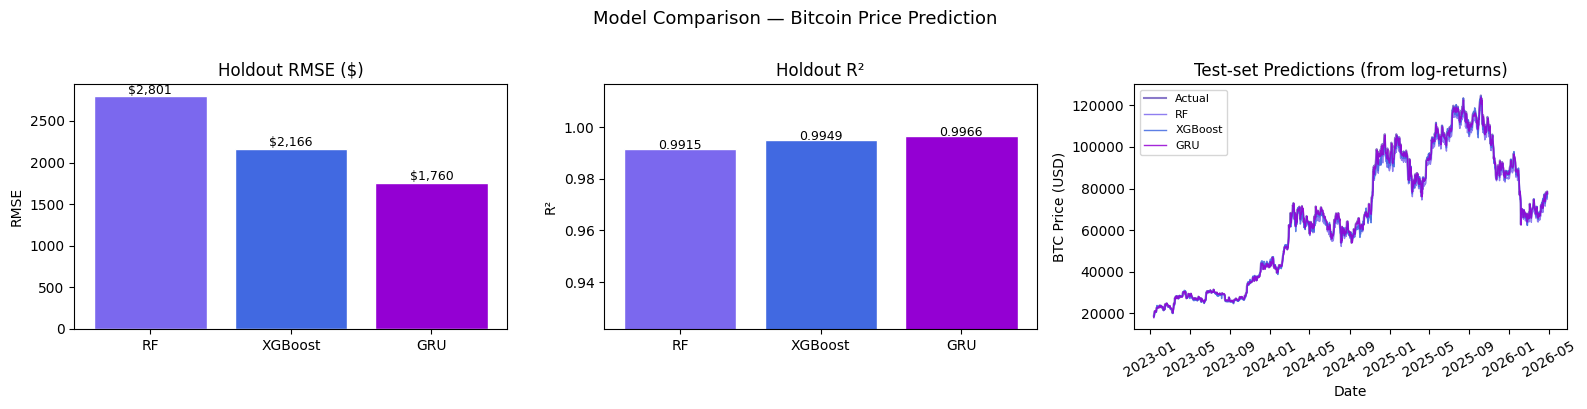


Best model: GRU


In [9]:

# ── Cell 9: Comparison plots ──────────────────────────────────────────────────
PALETTE = {
    "RF":      "#7B68EE",  # medium slate blue
    "XGBoost": "#4169E1",  # royal blue
    "GRU":     "#9400D3",  # dark violet
    "Close":   "#8A79C9",  # muted lavender (actual prices)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Holdout RMSE bar ─────────────────────────────────────────────────────────
ax = axes[0]
names_h  = list(holdout_df.index)
rmse_h   = holdout_df["RMSE"].astype(float).values
colors_h = [PALETTE.get(n, "#999") for n in names_h]
ax.bar(names_h, rmse_h, color=colors_h, edgecolor="white")
ax.set_title("Holdout RMSE ($)", fontsize=12)
ax.set_ylabel("RMSE")
for i, v in enumerate(rmse_h):
    ax.text(i, v + max(rmse_h) * 0.01, f"${v:,.0f}", ha="center", fontsize=9)

# ── Holdout R² bar ───────────────────────────────────────────────────────────
ax = axes[1]
r2_h = holdout_df["R2"].astype(float).values
colors_r2 = colors_h
ax.bar(names_h, r2_h, color=colors_r2, edgecolor="white")
ax.set_title("Holdout R²", fontsize=12)
ax.set_ylabel("R²")
r2_min = min(r2_h)
ax.set_ylim(r2_min - abs(r2_min) * 0.05 - 0.02, max(r2_h) + 0.02)
for i, v in enumerate(r2_h):
    ax.text(i, v + (max(r2_h) - r2_min) * 0.02, f"{v:.4f}", ha="center", fontsize=9)

# ── Predictions vs Actuals (reconstructed prices) ────────────────────────────
ax = axes[2]
ax.plot(dates_test.values, close_test_actual, color=PALETTE["Close"],   lw=1.5, label="Actual")
ax.plot(dates_test.values, rf_pred,           color=PALETTE["RF"],      lw=1, alpha=0.85, label="RF")
if xgb_model:
    ax.plot(dates_test.values, xgb_pred,      color=PALETTE["XGBoost"], lw=1, alpha=0.85, label="XGBoost")
ax.plot(dates_test.values, gru_pred,          color=PALETTE["GRU"],     lw=1, alpha=0.85, label="GRU")
ax.set_title("Test-set Predictions (from log-returns)", fontsize=12)
ax.set_xlabel("Date"); ax.set_ylabel("BTC Price (USD)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=30)

plt.suptitle("Model Comparison — Bitcoin Price Prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print(f"\nBest model: {best_name}")


Naive RF trained
Naive XGB trained
Naive GRU trained

=== Naive (no log-return) metrics — raw price target ===
             RMSE       MAE      R2
RF       23468.99  15101.47  0.4000
GRU      10788.09   7440.51  0.8732
XGBoost  26783.66  18157.40  0.2185


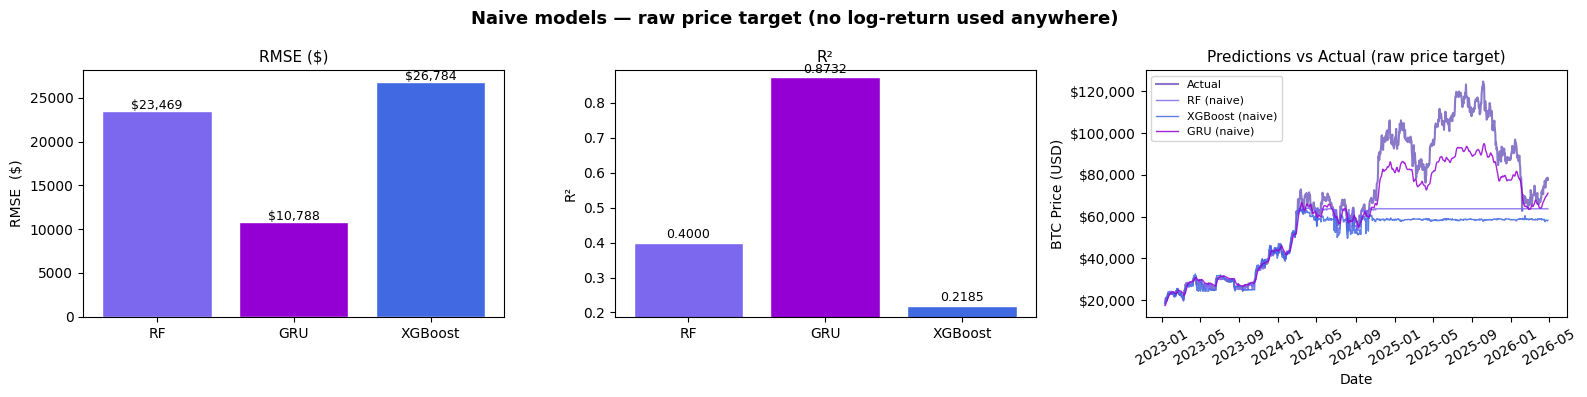


=== RMSE comparison: naive (raw price) vs log-return approach ===
         RMSE naive ($)  RMSE log-return ($)  difference ($)
GRU            10788.09              1759.92         9028.17
RF             23468.99              2801.05        20667.94
XGBoost        26783.66              2165.74        24617.92


In [10]:
# ── Cell 10: Naive models — predict raw price directly (no log-return) ───────
#
# Here we retrain the same three models but with the raw Close price as target.
# No log-return transformation is used anywhere: the model learns to output a dollar value.
#
# This is the "naive" approach many beginners use — and it illustrates the problems:
#   • The target is non-stationary (price drifts from $300 → $90,000+)
#   • Tree models can't extrapolate beyond training price range
#   • GRU has to memorise the absolute price scale instead of learning direction/magnitude of change

# ── Raw price targets (no transformation) ────────────────────────────────────
y_raw        = df["Close"].copy()
y_raw_train  = y_raw.iloc[:split].values
y_raw_test   = y_raw.iloc[split:].values

# Scale raw prices (StandardScaler — prices span $300–$100k+, need normalisation)
scaler_y_raw = StandardScaler()
y_raw_train_s = scaler_y_raw.fit_transform(y_raw_train.reshape(-1, 1)).ravel()
y_raw_test_s  = scaler_y_raw.transform(y_raw_test.reshape(-1, 1)).ravel()

# ── Train naive models ────────────────────────────────────────────────────────
rng = CONFIG["seed"]

rf_naive = RandomForestRegressor(n_estimators=CONFIG["n_estimators"], n_jobs=-1, random_state=rng)
rf_naive.fit(X_train_s, y_raw_train_s)
print("Naive RF trained")

xgb_naive = None
if HAS_XGB:
    xgb_naive = xgb.XGBRegressor(n_estimators=CONFIG["n_estimators"],
                                   n_jobs=-1, random_state=rng, verbosity=0)
    xgb_naive.fit(X_train_s, y_raw_train_s)
    print("Naive XGB trained")

gru_naive = Sequential([GRU(64, input_shape=(LOOKBACK, 1)), Dense(1)])
gru_naive.compile(optimizer="adam", loss="mse")
gru_naive.fit(X_train_gru, y_raw_train_s, epochs=CONFIG["gru_epochs"], batch_size=32, verbose=0)
print("Naive GRU trained")

# ── Predict & unscale directly to USD (no exp, no close_prev multiplication) ─
def unscale_price(scaled_pred):
    return scaler_y_raw.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()

rf_naive_pred  = unscale_price(rf_naive.predict(X_test_s))
gru_naive_pred = unscale_price(gru_naive.predict(X_test_gru, verbose=0).ravel())
xgb_naive_pred = unscale_price(xgb_naive.predict(X_test_s)) if xgb_naive else None

# ── Metrics ───────────────────────────────────────────────────────────────────
naive = {"RF": metrics(y_raw_test, rf_naive_pred), "GRU": metrics(y_raw_test, gru_naive_pred)}
if xgb_naive_pred is not None:
    naive["XGBoost"] = metrics(y_raw_test, xgb_naive_pred)

naive_df = pd.DataFrame(naive).T
print("\n=== Naive (no log-return) metrics — raw price target ===")
print(naive_df.to_string())

# ── Plots ─────────────────────────────────────────────────────────────────────
naive_names  = list(naive_df.index)
naive_colors = [PALETTE.get(n, "#999") for n in naive_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Naive models — raw price target (no log-return used anywhere)", fontsize=13, fontweight="bold")

# RMSE bar
rmse_n = naive_df["RMSE"].astype(float).values
axes[0].bar(naive_names, rmse_n, color=naive_colors, edgecolor="white")
axes[0].set_title("RMSE ($)", fontsize=11)
axes[0].set_ylabel("RMSE  ($)")
for i, v in enumerate(rmse_n):
    axes[0].text(i, v + max(rmse_n) * 0.01, f"${v:,.0f}", ha="center", fontsize=9)

# R² bar
r2_n = naive_df["R2"].astype(float).values
axes[1].bar(naive_names, r2_n, color=naive_colors, edgecolor="white")
axes[1].set_title("R²", fontsize=11)
axes[1].set_ylabel("R²")
r2_min_n = min(r2_n)
axes[1].set_ylim(r2_min_n - abs(r2_min_n) * 0.05 - 0.02, max(r2_n) + 0.02)
for i, v in enumerate(r2_n):
    axes[1].text(i, v + (max(r2_n) - r2_min_n) * 0.02, f"{v:.4f}", ha="center", fontsize=9)

# Predictions vs actuals
axes[2].plot(dates_test.values, y_raw_test,      color=PALETTE["Close"],   lw=1.5, label="Actual")
axes[2].plot(dates_test.values, rf_naive_pred,   color=PALETTE["RF"],      lw=1, alpha=0.85, label="RF (naive)")
if xgb_naive_pred is not None:
    axes[2].plot(dates_test.values, xgb_naive_pred, color=PALETTE["XGBoost"], lw=1, alpha=0.85, label="XGBoost (naive)")
axes[2].plot(dates_test.values, gru_naive_pred,  color=PALETTE["GRU"],     lw=1, alpha=0.85, label="GRU (naive)")
axes[2].set_title("Predictions vs Actual (raw price target)", fontsize=11)
axes[2].set_xlabel("Date")
axes[2].set_ylabel("BTC Price (USD)")
axes[2].legend(fontsize=8)
axes[2].tick_params(axis="x", rotation=30)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# ── Side-by-side RMSE comparison: naive vs log-return ─────────────────────────
print("\n=== RMSE comparison: naive (raw price) vs log-return approach ===")
compare = pd.DataFrame({
    "RMSE naive ($)":      naive_df["RMSE"].astype(float),
    "RMSE log-return ($)": holdout_df["RMSE"].astype(float),
})
compare["difference ($)"] = compare["RMSE naive ($)"] - compare["RMSE log-return ($)"]
print(compare.to_string())
